# <font color='green'>Ambiente de Análise Integrado aos Dados da PDD-Cidacs</font>
## <font color='#8B0000'>Biblioteca PDD-Cidacs Lib?</font>

### 1. O que é a PDD-Cidacs Lib?

Consiste em um cliente python que serve de interface à API de consumo de dados da PDD-Cidacs. Foi desenvolvida para facilitar a extração dos conjuntos de dados hospedados no Google BigQuery através da execucação de querys utilizando sintaxe baseada em linguagem SQL.

### 2. Quais são os requisitos para utilizar?

1. Cadastro de usuário e acesso ao site da PDD: http://pdd.cidacs.org/ <br>
2. Seleção e vinculação dos datasets de interesse ao perfil de usuário <br>
3. Download da biblioteca disponível do Github: https://github.com/marconso/pdd-cidacs-lib.git <br>
4. Obtenção do Token de acesso através do site da PDD <br>
5. Importação da biblioteca em um ambiente Python

### 3. Como utilizar? 

### 3.1 Importando a biblioteca e instanciando um Cliente

In [1]:
import sys
#adiciona o caminho onde está a pasta da biblioteca com o arquivo 'bib_pdd_cidacs.py'
sys.path.append('pdd-cidacs-lib-main/pdd_lib')

In [2]:
import numpy
import pandas
print(numpy.__version__)
print(pandas.__version__) 


2.1.3
2.2.3


In [3]:
#importando a biblioteca
from bib_pdd_cidacs import BibPddCidacs
#importando a biblioteca auxiliar de analise de dados
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
#instanciando um cliente
client = BibPddCidacs()

In [5]:
help(client)

Help on BibPddCidacs in module bib_pdd_cidacs object:

class BibPddCidacs(builtins.object)
 |  Methods defined here:
 |
 |  authentication(self, cred: Union[str, pathlib.PosixPath, dict, NoneType] = None) -> dict
 |
 |  download(self, query, filename=None)
 |
 |  list_columns(self, dataset)
 |
 |  list_db(self)
 |
 |  query(self, query)
 |
 |  shape(self, dataset)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



### 3.2 Autenficação na biblioteca usando as credenciais de usuário da PDD

Para autenticação é preciso que o usuário substitua os dados do template com os seus dados de e-mail e o seu token.

In [6]:
credentials = {
    "email": "mikael.coletto.eng@gmail.com",
    "token": "qhWfbepBkUktQq5iE2puUFaY"
}

client.authentication(credentials)

### 3.3 Listando os datasets associados ao perfil do usuário

In [15]:
dbs = client.list_db()

print('Meus Datasets:')
for cod in sorted(list(dbs.keys())):
    print(f'Código: {cod}', f' -   Dataset: {dbs[cod]}')

Meus Datasets:
Código: 14  -   Dataset: Hospitalizações por todas as causas no Brasil (SIH) - a partir de 2020
Código: 205  -   Dataset: Acidentes de Trabalho
Código: 4  -   Dataset: Sistema de Informação Sobre Nascidos Vivos (SINASC) - a partir de 2020


### 3.4. Quantidade de registros e de variáveis de um dataset

In [ ]:
# Sistema de Informação de Mortalidade - a partir de 1979
dataset = 14
quant_registros = client.shape(dataset="14")
print(f'Qt. de registros: {quant_registros[0]}, Qt. de variáveis {quant_registros[1]}')


TypeError: initial_value must be str or None, not dict

In [11]:
# Sistema de Informações Hospitalares/SUS- a partir de 1992
dataset = 4
quant_registros = client.shape(dataset=dataset)
print(f'Qt. de registros: {quant_registros[0]}, Qt. de variáveis {quant_registros[1]}')


TypeError: initial_value must be str or None, not dict

### 3.5. Listando as colunas

In [9]:
dataset = 14 # SINASC
lista_nome_variaveis = client.list_columns(dataset=dataset)
lista_nome_variaveis

TypeError: initial_value must be str or None, not dict

In [21]:
lista_nome_variaveis

['HEPATITE_N',
 'CS_RACA',
 'TATU_PIER',
 'ID_OCUPA_N',
 'ACUPUNTURA',
 'ANTIHAVIGM',
 'ANTIHBCIGM',
 'COLETAMARC',
 'DT_NOTIFIC',
 'CS_ESCOL_N',
 'HEPATITB',
 'TRESMAIS',
 'HIV',
 'DOMICILI',
 'ANTIHDVIGM',
 'ID_REGIONA',
 'ID_MUNICIP',
 'ANTIHCV',
 'NU_LOTE_I',
 'AGHBS',
 'FONTE',
 'OUTRAS',
 'OUTRA_DST',
 'FORMA',
 'HEMODIALIS',
 'ANTIHEVIGM',
 'ID_AGRAVO',
 'AGUA_ALIME',
 'CO_UF_EX3',
 'SG_UF_NOT',
 'OCUPACIO',
 'INSTITUCIO',
 'CO_MUN_EX3',
 'ANTIHDV',
 'INAL_CRACK',
 'TRANSFUSAO',
 'CLASSI_FIN',
 'DT_ENCERRA',
 'HEPATITA',
 'DT_ACIDENT',
 'CLAS_ETIOL',
 'NU_ANO',
 'MATBIOLOGI',
 'CO_MUN_EX2',
 'GEN_VHC',
 'BANCOSANGU',
 'ANTIHBE',
 'CO_MUN_EXP',
 'RE_ANTIHBC',
 'NU_IDADE_N',
 'ANTIHBS',
 'TP_SOROHCV',
 'MEDICAMENT',
 'SEM_NOT',
 'ID_MN_RESI',
 'RE_ANTIHCV',
 'AGHBE',
 'DENTARIO',
 'CS_SEXO',
 'CO_UF_EXP',
 'CO_UF_EX2',
 'HBC_TOTAL',
 'ID_PAIS',
 'ID_RG_RESI',
 'DT_COLETA',
 'INJETAVEIS',
 'TRANSPLA',
 'SEXUAL',
 'CIRURGICO',
 'SG_UF',
 'CS_GESTANT',
 'TP_NOT',
 'DSFONTE',
 'RES_HB

### 3.6 Fazendo Querys

In [13]:
df_mun_semiarido = pd.read_excel('/home/imaster_rafa/Área de Trabalho/CIDACS/scripts/Tutorial Biblioteca PDD/lista_municipios_Semiarido_2022.xlsx')
df_mun_semiarido['CodigoIbge6'] = [int(str(cod)[:6]) for cod in df_mun_semiarido['CD_MUN'].to_list()]

In [15]:
lista_mun_semiarido = df_mun_semiarido['CodigoIbge6'].to_list()

I20-I25: Doenças isquêmicas do coração <br>
I30-I52: Outras formas de doenças do coração

In [26]:
dataset = 240
query = f"SELECT  __PDD_DTOBITO_ANO as ANO, CODMUNRES, SEXO, COUNT (*) AS OBITO \
FROM {dataset}  WHERE REGEXP_CONTAINS(CAUSABAS, r'^I(2[0-5]|[3-5][0-9])') \
AND __PDD_DTOBITO_ANO >= '2000' AND __PDD_DTOBITO_ANO <= '2019'\
AND IDADE >= '14' AND IDADE <= '24' \
GROUP BY __PDD_DTOBITO_ANO, CODMUNRES, SEXO"

r_fx_14a24 = client.query(query = query)

In [27]:
dataset = 240
query = f"SELECT  __PDD_DTOBITO_ANO as ANO, CODMUNRES, SEXO, COUNT (*) AS OBITO \
FROM {dataset}  WHERE REGEXP_CONTAINS(CAUSABAS, r'^I(2[0-5]|[3-5][0-9])') \
AND __PDD_DTOBITO_ANO >= '2000' AND __PDD_DTOBITO_ANO <= '2019'\
AND IDADE >= '25' AND IDADE <= '35' \
GROUP BY __PDD_DTOBITO_ANO, CODMUNRES, SEXO"

r_fx_25a35 = client.query(query = query)

In [38]:
r_fx_14a24['FX'] = '14 a 24'
r_fx_25a35['FX'] = '25 a 35'

In [40]:
r_fx_14a35 = pd.concat([r_fx_14a24, r_fx_25a35])
#r_fx_14a35['OBITO'].sum()

In [42]:
r_fx_14a35['OBITO'].sum()

5706

In [43]:
df_result = r_fx_14a35.loc[r_fx_14a35['CODMUNRES'].isin(lista_mun_semiarido)]

In [45]:
df_result['OBITO'].sum()

707

In [54]:
df_result

,ANO,CODMUNRES,SEXO,OBITO,FX
6,2007,220270,2,1,14 a 24
9,2006,231030,2,1,14 a 24
10,2007,230350,2,1,14 a 24
11,2006,251640,1,1,14 a 24
12,2017,250940,2,1,14 a 24
...,...,...,...,...,...
4206,2018,291080,2,1,25 a 35
4209,2018,291810,1,1,25 a 35
4222,2016,230300,2,1,25 a 35
4223,2016,230640,1,2,25 a 35


In [55]:
df_result_ano = df_result.groupby('ANO')['OBITO'].sum()
df_result_ano = df_result_ano.reset_index()
df_result_ano

,ANO,OBITO
0,2006,58
1,2007,72
2,2008,68
3,2009,56
4,2010,56
5,2011,51
6,2012,43
7,2013,39
8,2014,55
9,2015,46


<BarContainer object of 14 artists>

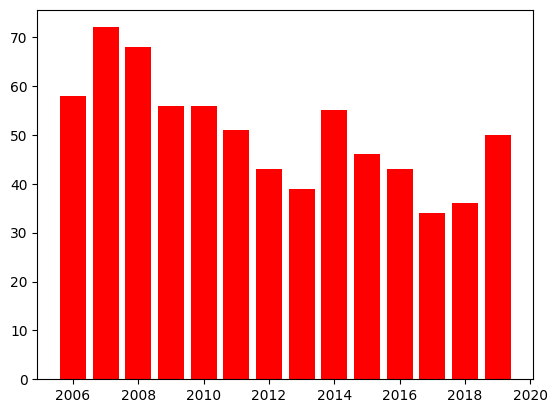

In [56]:
plt.bar(df_result_ano['ANO'].to_list(), df_result_ano['OBITO'].to_list(), color='red')